# BSRNN workbook
The aim for this workbook is to start designing the components of the BSRNN from the 'High Fidelity Speech Enhancement BSRNN' paper.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
import soundfile as sf
import time
from collections import defaultdict
import math
import yaml

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --- make `src.*` importable from this notebook -------------------------------
# Mirrors the sys.path.insert that scripts/ use. Walks up for CLAUDE.md so it
# works regardless of where the kernel was started.
import sys
from pathlib import Path as _Path

_root = _Path.cwd()
while not (_root / "CLAUDE.md").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f"repo root on sys.path: {_root}")


Using device: cpu
repo root on sys.path: /home/grant/Documents/University/Masters/Project/TargetSpeakerExtractor


In [2]:
# Load configs
def load_config(model_yaml="bsrnn_baseline.yaml", repo_root=None):
    root = Path(repo_root or Path.cwd())
    while not (root / "CLAUDE.md").exists() and root != root.parent:
        root = root.parent
    cfgs = root / "experiments" / "configs"
    
    model = yaml.safe_load((cfgs / model_yaml).read_text())
    gen   = yaml.safe_load((cfgs / "generator.yaml").read_text())
    
    # Single source of truth: the rate the data was rendered at.
    model["sample_rate"] = gen["sample_rate"]
    return model, root

cfg, ROOT = load_config()
sr     = cfg["sample_rate"]
n_fft  = cfg["model"]["stft"]["n_fft"]
hop    = cfg["model"]["stft"]["hop"]
k      = cfg["model"]["lookahead_frames"]
lstm_hidden_dim = cfg["model"]["separator"]["lstm_hidden"]




In [ ]:
from src.data.dataset_loader import TrialDataset

In [4]:
smoke_train_dataset = TrialDataset(
    manifest_csv="./../../data/manifests/smoke_train.csv",
    data_root="./../../data",
    split="smoke_train",
    chunk_s=4.0, # follow CARTSE
    sample_rate=16000,
    seed=42
)

smoke_valid_dataset = TrialDataset(
    manifest_csv="./../../data/manifests/smoke_val.csv",
    data_root="./../../data",
    split="smoke_val",
    chunk_s=4.0, # follow CARTSE
    sample_rate=16000,
    seed=42,
    random_crop=False,
)

smoke_train_loader = torch.utils.data.DataLoader(
    smoke_train_dataset,
    batch_size=12, # Follow CARTSE
    shuffle=True,
    num_workers=4
)

smoke_valid_loader = torch.utils.data.DataLoader(
    smoke_valid_dataset,
    batch_size=12, # Follow CARTSE
    shuffle=False,
    num_workers=4
)

In [5]:
# Example of how to use the dataset and dataloader
for batch in smoke_train_loader:
    mixture = batch["mixture"]
    target = batch["target"]
    enrollment = batch["enrollment"]
    crop_absent = batch["crop_absent"]
    trial_id = batch["trial_id"]
    meta = batch["meta"]

    print(f"Mixture shape: {mixture.shape}")
    print(f"Target shape: {target.shape}")
    print(f"Enrollment shape: {enrollment.shape}")
    print(f"Crop absent: {crop_absent}")
    print(f"Trial ID: {trial_id}")
    print(f"Meta: {meta}")
    break  # Just process one batch for demonstration 

Mixture shape: torch.Size([12, 64000])
Target shape: torch.Size([12, 64000])
Enrollment shape: torch.Size([12, 80000])
Crop absent: tensor([False,  True,  True, False, False, False, False, False,  True,  True,
        False, False])
Trial ID: ['smoke_train-42-000034', 'smoke_train-42-000017', 'smoke_train-42-000045', 'smoke_train-42-000023', 'smoke_train-42-000022', 'smoke_train-42-000031', 'smoke_train-42-000042', 'smoke_train-42-000033', 'smoke_train-42-000036', 'smoke_train-42-000003', 'smoke_train-42-000014', 'smoke_train-42-000002']
Meta: {'condition': ['both', 'interferer_only', 'interferer_only', 'target_only', 'both', 'target_only', 'both', 'both', 'interferer_only', 'noise_only', 'both', 'both'], 'clip_absent': tensor([False,  True,  True, False, False, False, False, False,  True,  True,
        False, False]), 'sir_db': tensor([4.6800,    nan,    nan,    nan, 8.7300,    nan, 8.9600, 9.8600,    nan,
           nan, 8.8500, 6.1900], dtype=torch.float64), 'snr_db': tensor([10.19

In [6]:
# Need to just validate that the crops that I make still align to the split of data with the 50% both, 25% target only, 20% interfere only, and 5% noise only
def measure_empty_crops(ds, n_trials=3000, epochs=3, sample_seed=0):
    """Fraction of crops that contain no target speech, per epoch and condition.
    
    Reuses the dataset's own crop-offset RNG so the offsets are exactly the ones
    training will draw. Reads only target.wav — mixture and enrollment are not
    needed to answer this.
    """
    rng = np.random.default_rng(sample_seed)
    idxs = rng.choice(len(ds), size=min(n_trials, len(ds)), replace=False)
    
    n_frames_cache = {}          # frames don't change across epochs
    rows = []
    t0 = time.perf_counter()
    
    for ep in range(epochs):
        ds.set_epoch(ep)
        for i in idxs:
            i = int(i)
            r = ds.manifest_df.iloc[i]
            tdir = ds.data_root / "rendered" / ds.split / r["trial_id"]
            
            if i not in n_frames_cache:
                n_frames_cache[i] = sf.info(str(tdir / "mixture.wav")).frames
            start = ds._crop_offset_start(i, n_frames_cache[i])
            
            tgt = ds._read_in_wav(tdir / "target.wav",
                                start=start, frames=ds.chunk_frames)
                                 
            rows.append({         
                "epoch":       ep,
                "condition":   r["condition"],
                "clip_absent": bool(r["target_absent"]),
                "crop_absent": bool(tgt.abs().max() == 0),
                "activity":    float(r["target_activity"]),
            })  
              
    print(f"{len(rows)} crops in {time.perf_counter()-t0:.1f}s")
    return pd.DataFrame(rows)                    


In [7]:
# train_dataset = TrialDataset(
#     manifest_csv="./../../data/manifests/train.csv",
#     data_root="./../../data",
#     split="train",
#     chunk_s=4.0,
#     sample_rate=16000,
#     seed=42,
#     random_crop=True,
# )

# df = measure_empty_crops(train_dataset, n_trials=3000, epochs=3)

# designed  = df["clip_absent"].mean()      # what the generator was configured for
# effective = df["crop_absent"].mean()      # what the model actually trains on
# present   = df[~df["clip_absent"]]
# leakage   = present["crop_absent"].mean()

# print(f"designed  absent rate (clip level) : {designed:.3f}")
# print(f"effective absent rate (crop level) : {effective:.3f}")
# print(f"drift                              : {effective - designed:+.3f}")
# print(f"leakage (present trial -> silent crop): {leakage:.3f}")

# print("\nleakage by condition:")
# print(present.groupby("condition")["crop_absent"].agg(["mean", "count"]))

# print("\nleakage by target_activity band:")
# banded = present.assign(band=pd.cut(present["activity"], [0, .2, .3, .4, .5, .6, .8]))
# print(banded.groupby("band", observed=True)["crop_absent"].agg(["mean", "count"]))

# print("\nper-epoch effective rate (should be stable):")
# print(df.groupby("epoch")["crop_absent"].mean())


## 1. Create the STFT

In [8]:
from src.models.stft import STFT

# Extracted to src/models/ -- definition kept below for reference only.

# class STFT(nn.Module):
#     def __init__(self, n_fft=512, hop_length=128, sample_rate=16000):
#         super().__init__()
#         self.n_fft = n_fft
#         self.hop_length = hop_length
#         self.sample_rate = sample_rate
#         self.padding = n_fft - hop_length
#         self.register_buffer("window", torch.hann_window(n_fft), persistent=False)
    
          
#     def latency_ms(self, lookahead_frames=0):
#         """Algorithmic latency. Convention: window fill + emit hop + lookahead.
#         State the convention when you quote it -- CARTSE counts window - hop
#         instead, so their 24 ms and our 40 ms describe the same framing."""
#         samples = self.n_fft + self.hop_length + lookahead_frames * self.hop_length
#         return 1000 * samples / self.sample_rate 

#     def _n_frames(self, T):
#       # +2*padding: the tail needs the same ramp-out room the head gets, or the
#       # final samples land where the OLA envelope has decayed to ~0.
#       return math.ceil((T + 2 * self.padding - self.n_fft) / self.hop_length) + 1
 
#     # (B, T) -> (B, F, N) complex
#     def forward(self, x):                        
#         T = x.shape[-1]
#         n_frames = self._n_frames(T)
#         right = (n_frames - 1) * self.hop_length + self.n_fft - (T + self.padding)
#         xp = F.pad(x, (self.padding, right))
#         return torch.stft(xp, self.n_fft, self.hop_length, self.n_fft,
#                             self.window, center=False, return_complex=True)

#     # (B, F, N) complex -> (B, length)                  
#     def inverse(self, X, length):              
#         frames = torch.fft.irfft(X, n=self.n_fft, dim=1) * self.window[None, :, None]
#         B, _, N = frames.shape
#         total = (N - 1) * self.hop_length + self.n_fft
#         fold = lambda t: F.fold(t, (1, total), (1, self.n_fft), stride=(1, self.hop_length))
        
#         out = fold(frames).view(B, total)
#         env = fold(self.window.pow(2)[None, :, None].expand(1, -1, N)).view(total)
#         return (out / env.clamp_min(1e-11))[:, self.padding:self.padding + length]





In [9]:
# example test STFT
f = STFT()
x = torch.randn(2, 64000)
print("round-trip:", (f.inverse(f(x), 64000) - x).abs().max().item())   # expect ~7e-7
print("latency k=0:", f.latency_ms(0), "ms   k=16:", f.latency_ms(16), "ms")

round-trip: 9.5367431640625e-07
latency k=0: 40.0 ms   k=16: 168.0 ms


In [10]:
f = STFT()
for T in (64000, 63999, 12345):          # odd lengths matter — 64000 hides padding bugs
    x = torch.randn(2, T)
    err = (f.inverse(f(x), T) - x).abs().max()
    assert err < 1e-5, f"T={T}: {err}"
    print(f"T={T}: {err:.2e}")


T=64000: 9.54e-07
T=63999: 9.54e-07
T=12345: 7.15e-07


## 2. Build the band plan table as a pure function


This is for breaking down the audio mixture into the subbands that will be used in the model. How it works is the mixture audio gets sent to a STFT, which will output a number of bins `n_fft`. I then group these bins according to some plan that I set in the config file.

In [ ]:
from src.models.bands import BAND_PRESETS


We need functions for ALL plans, so that we can test them and see if they are actually doing any work. The uniform plan is the control, and the other plans are the experimental conditions. If the uniform plan performs just as well as the other plans, then the non-uniformity is not actually doing any work.

In [ ]:
from src.models.bands import uniform_plan

In [ ]:
from src.models.bands import band_plan


In [14]:
from src.models.bands import BAND_PRESETS, band_plan

# Extracted to src/models/ -- definition kept below for reference only.

for name in BAND_PRESETS:
    w = band_plan(16000, 512, name)
    print(f"{name:14s} {len(w):3d} bands  sum={sum(w)}  min={min(w)}  max={max(w)}")


wesep_16k       32 bands  sum=257  min=3  max=64
uniform_32      32 bands  sum=257  min=8  max=9
yu_truncated    27 bands  sum=257  min=6  max=41
bark            22 bands  sum=257  min=3  max=41
mel_32          32 bands  sum=257  min=2  max=22
f0_focused      26 bands  sum=257  min=3  max=35


In [15]:
from src.models.bands import describe_plan

# Extracted to src/models/ -- definition kept below for reference only.

def describe_plan(widths, sample_rate, n_fft):
    hz, lo = sample_rate / n_fft, 0
    for i, w in enumerate(widths):
        print(f"band {i:2d}  bins {lo:3d}-{lo+w-1:3d} ({w:3d})  "
            f"{lo*hz:7.1f} - {(lo+w)*hz:7.1f} Hz")
        lo += w
        
widths = band_plan(16000, 512, "wesep_16k")
print(len(widths), "bands, sum =", sum(widths))     # expect 32 bands, sum 257
describe_plan(widths, 16000, 512)




32 bands, sum = 257
band  0  bins   0-  2 (  3)      0.0 -    93.8 Hz
band  1  bins   3-  5 (  3)     93.8 -   187.5 Hz
band  2  bins   6-  8 (  3)    187.5 -   281.2 Hz
band  3  bins   9- 11 (  3)    281.2 -   375.0 Hz
band  4  bins  12- 14 (  3)    375.0 -   468.8 Hz
band  5  bins  15- 17 (  3)    468.8 -   562.5 Hz
band  6  bins  18- 20 (  3)    562.5 -   656.2 Hz
band  7  bins  21- 23 (  3)    656.2 -   750.0 Hz
band  8  bins  24- 26 (  3)    750.0 -   843.8 Hz
band  9  bins  27- 29 (  3)    843.8 -   937.5 Hz
band 10  bins  30- 32 (  3)    937.5 -  1031.2 Hz
band 11  bins  33- 35 (  3)   1031.2 -  1125.0 Hz
band 12  bins  36- 38 (  3)   1125.0 -  1218.8 Hz
band 13  bins  39- 41 (  3)   1218.8 -  1312.5 Hz
band 14  bins  42- 44 (  3)   1312.5 -  1406.2 Hz
band 15  bins  45- 50 (  6)   1406.2 -  1593.8 Hz
band 16  bins  51- 56 (  6)   1593.8 -  1781.2 Hz
band 17  bins  57- 62 (  6)   1781.2 -  1968.8 Hz
band 18  bins  63- 68 (  6)   1968.8 -  2156.2 Hz
band 19  bins  69- 74 (  6)   

In [16]:
from src.models.bands import band_plan, uniform_plan

# Extracted to src/models/ -- definition kept below for reference only.

assert band_plan(16000, 512, "wesep_16k") == [3]*15 + [6]*10 + [16]*5 + [64] + [8]
assert sum(uniform_plan(512, 32)) == 257
assert sum(band_plan(16000, 1024, "wesep_16k")) == 513 

In [17]:
from src.models.bands import band_plan

# Instantiations, not definitions -- these objects are used by later cells.
widths = band_plan(sr, n_fft, cfg["model"]["bands"]["plan"])
stft   = STFT(n_fft=n_fft, hop_length=hop, sample_rate=sr)

print(f"{len(widths)} bands, {sum(widths)} bins, latency {stft.latency_ms(k)} ms")

32 bands, 257 bins, latency 40.0 ms


In [18]:
def plot_band_plan(X, widths, sample_rate, n_fft, hop, name="", max_s=4.0):
    """X: (F, N) complex spectrogram for one clip."""
    db = 20 * np.log10(X.abs().cpu().numpy() + 1e-8)
    keep = min(db.shape[1], int(max_s * sample_rate / hop))
    db, dur = db[:, :keep], keep * hop / sample_rate
    nyq = sample_rate / 2
    
    edges = np.minimum(np.cumsum([0] + list(widths)) * (sample_rate / n_fft), nyq)
    centres, bw = (edges[:-1] + edges[1:]) / 2, np.diff(edges)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True,
                                    gridspec_kw={"width_ratios": [3, 1]})
    ax1.imshow(db, origin="lower", aspect="auto", extent=[0, dur, 0, nyq],
                cmap="magma", vmin=db.max() - 80, vmax=db.max())
    for e in edges[1:-1]:
        ax1.axhline(e, color="cyan", lw=0.6, alpha=0.7)
    ax1.set_xlabel("time (s)"); ax1.set_ylabel("frequency (Hz)")
    ax1.set_title(f"{name} — {len(widths)} bands over {n_fft//2+1} bins")
    
    ax2.barh(centres, bw, height=bw * 0.85, color="steelblue")
    ax2.set_xlabel("band width (Hz)"); ax2.set_title("resolution")
    plt.tight_layout()
    return fig



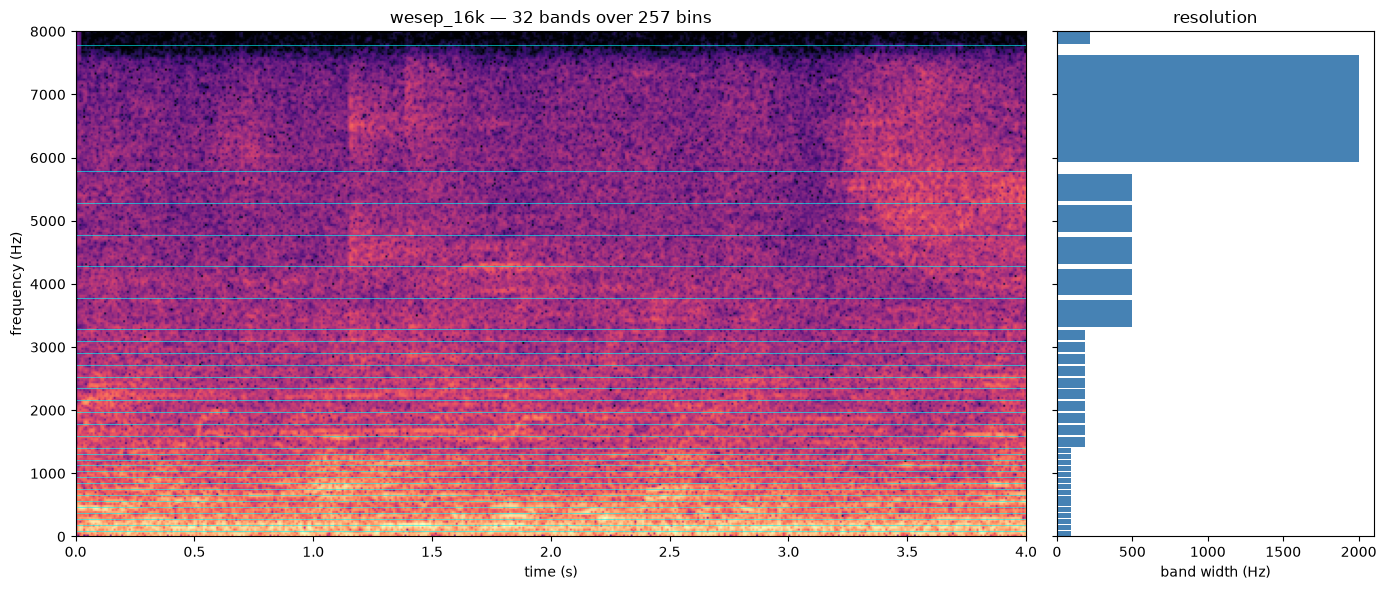

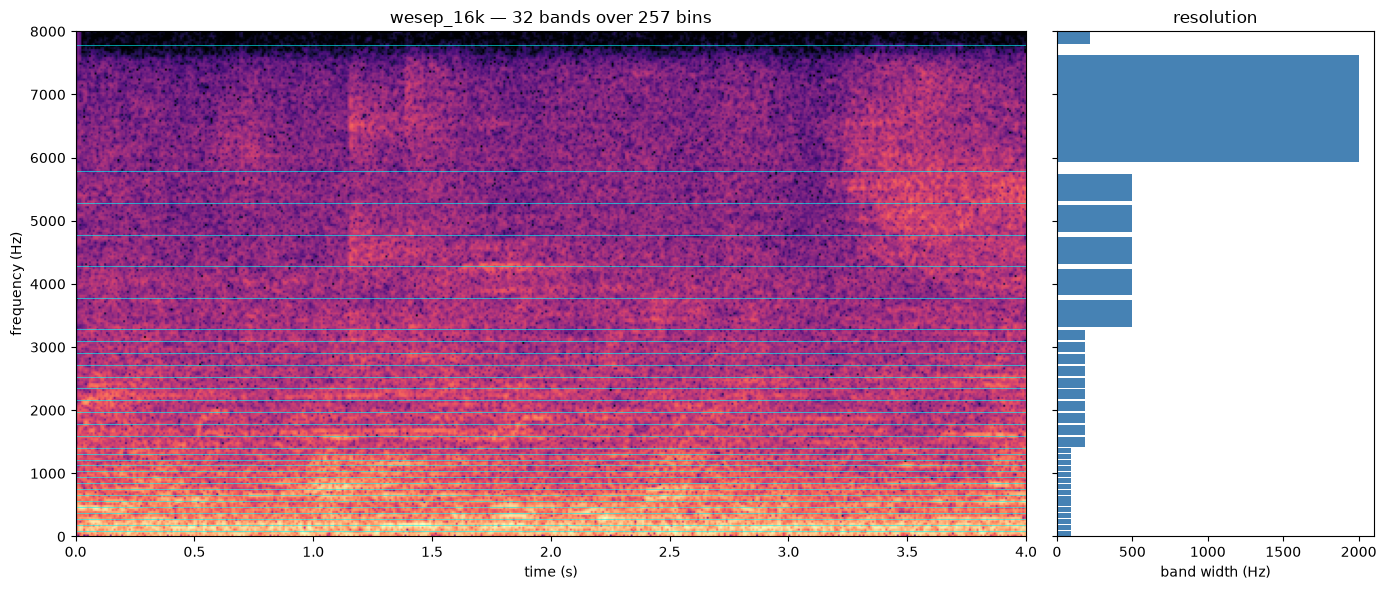

In [19]:
batch = next(iter(smoke_train_loader))
X = stft(batch["mixture"][0:1])[0]
plot_band_plan(X, band_plan(sr, n_fft, "wesep_16k"), sr, n_fft, hop, "wesep_16k")

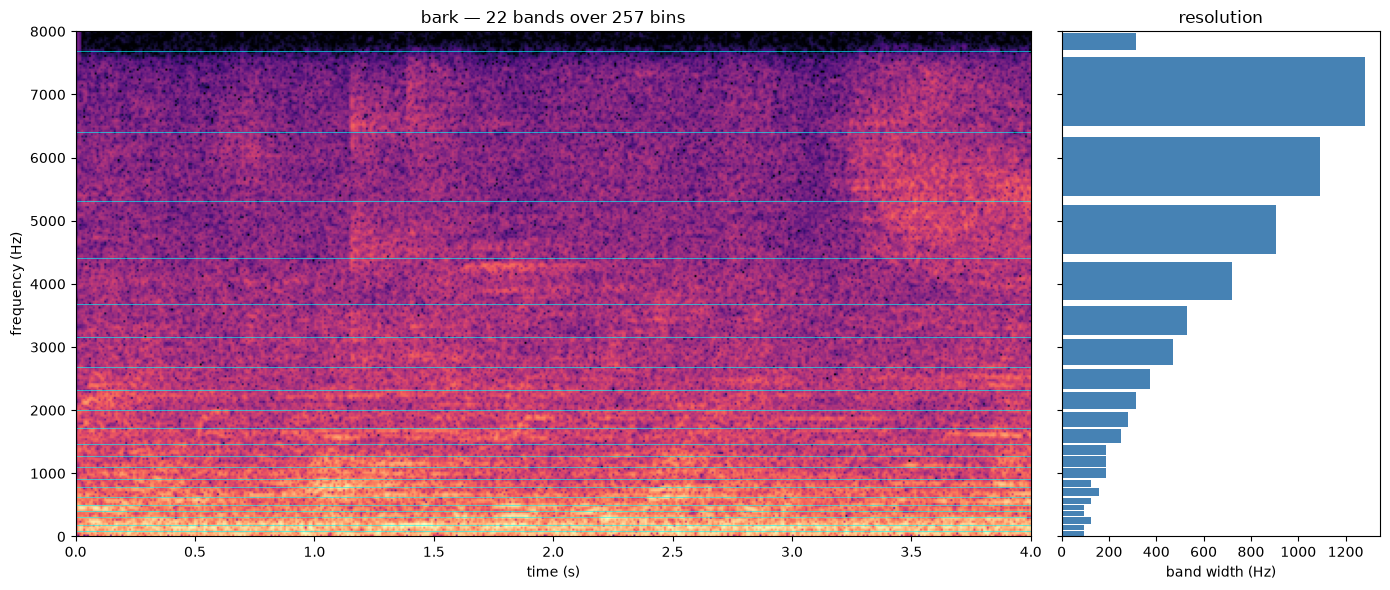

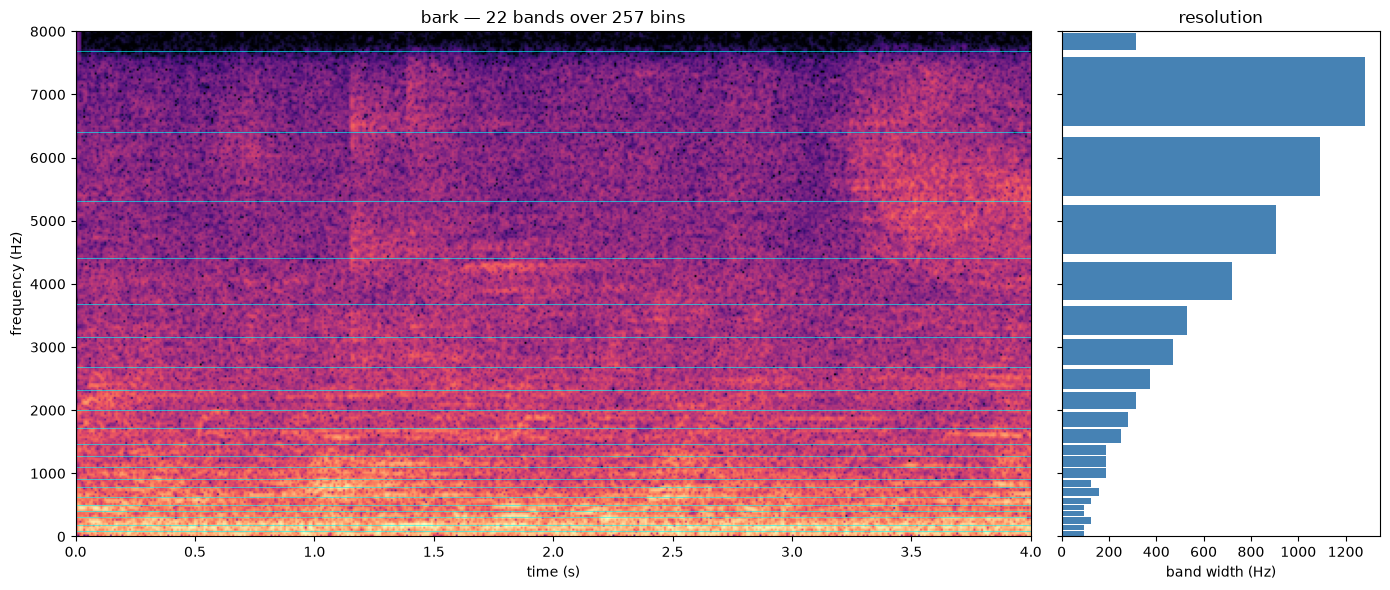

In [20]:
plot_band_plan(X, band_plan(sr, n_fft, "bark"), sr, n_fft, hop, "bark")

## 3. Build the Band Split
Need to slice the (B, C, F, T) into 32 band per band tensors using the widths that I built above. Needs to handle the complex spectrogram which is used for the mask multiply and then the real/imaginary stacked versions.
RMB:
- `B`: Batch-> How many clips we process at once which currently is set to 12
- `C`: Channels -> The feature axis which is set to 2. Will be 3 when we have TF-Map
- `F`: Frequency bins -> 257, the number of bins produced by the STFT
- `T`: Time frames -> 503 calculated using the 4s chunks

Why you split the same spectrogram twice

  This is the part that looks redundant and isn't. Your STFT produces one complex tensor (B, F, T). You need it in two forms:

  (B, 257, T) complex        → split → 32 bands → KEPT ASIDE
                                                  for the mask multiply at the end
                                                 
  (B, 2, 257, T) real/imag   → split → 32 bands → FED TO THE NETWORK
                                                  (SubbandNorm projects each to 128)


Note that due to the different widths we cannot stack these tensors yet. That is what the  SubbandNorm layer will do to project every band to a shared dimensionality. The SubbandNorm layer will be used in the model to project every band to a shared dimensionality, allowing for stacking and further processing.

In [ ]:
from src.models.modules import BandSplit

In [22]:
widths = band_plan(sr, n_fft, "wesep_16k")
bs = BandSplit(widths)

X = torch.randn(12, 257, 503, dtype=torch.complex64)      
bands = bs(X)
assert len(bands) == len(widths) == 32
assert [b.shape[-2] for b in bands] == widths
assert torch.equal(torch.cat(bands, dim=-2), X)           

Xri = torch.randn(12, 2, 257, 503)                        
assert torch.equal(torch.cat(bs(Xri), dim=-2), Xri)

try:                                                      
    bs(torch.randn(12, 2, 513, 503))
except AssertionError as e:
    
    print("guard OK:", e)


guard OK: 513 bins but band plan covers 257


## 4. Per-Band Normalization
This module is used to project every band to a shared dimensionality, allowing for stacking and further processing. Each band needs to receive its own normalisation and its own FC. 

In [ ]:
from src.models.modules import ChannelWiseLayerNorm, SubbandNorm

## 5. Residual LSTM block
An LSTM walks along a sequence one step at a time, carrying a hidden state, a memory of what it has seen so far. At each step it combines the new input with that memory and produces an output.

The sequence is time: 503 frames. So it walks frame by frame, and its memory at frame 200 contains a summary of frames 0-199.
That memory is what lets it decide "the target speaker was talking a moment ago, this energy is probably still theirs."

That's the whole reason to use a recurrent model rather than treating each frame independently.

1. The residual -> It is always a good idea to pass the input through a model unchanged so that there is a direct path backwards if a transformation leads to destroying signal. The idea comes from He et al. (2016), ResNet.

2. Why do we need projections -> Currently I will use 128 dimensional features per band. The High Fidelity paper uses a 192-wide LSTM. Ie with an output of 192 from the LSTM, we need to add them to the 128 wide input, but we need to first create a mapping between the two to allow this addition.

3. We need to normalise before the LSTM to prevent the residual from becoming dirty.

4. We are going to use this architecture for two different axes, one bidirectional and the other only one direction. Since the LSTM follows sequences, we only need to change/reshape the sequence axis for it to apply to another domain. Time for one cant be bidirectional, but bands can be. On the bands we can move up and down the frequency axis and not left adn right on the time axis.


In [ ]:
from src.models.modules import ResRNN


## 6. BSNet and the Band Sequence Model

  After SubbandNorm you have one tensor:

  (B, K, N, T)  =  (12, 32, 128, 503)
   │  │  │  └── 503 time frames
   │  │  └───── 128 features per band
   │  └──────── 32 bands
   └─────────── 12 clips
   
  ResRNN wants (B', N, L) — batch, features, sequence. So for each of the two calls, the job is to arrange the tensor so the axis you want
  modelled sits in the L position, and everything that should be treated as independent gets folded into B'.
  
  ---

  Call 1: band_rnn — walk along TIME
  
  What should be a sequence? Time, 503 long.
  What should be independent? Every (clip, band) pair. Band 3 of clip 0 evolves separately from band 20 of clip 0.
  
  So the target is (B*K, N, T) = (384, 128, 503) — 384 independent time-sequences.

  Getting there is easy, because B and K are already adjacent and already in the right order:
 
  x.reshape(B * K, N, T)

---

  Call 2: band_comm — walk across BANDS

  What should be a sequence? Bands, 32 long.
  What should be independent? Every (clip, frame) pair. The 32 bands at frame 100 form one sequence; the 32 bands at frame 101 form a
  different one.

  So the target is (B*T, N, K) = (6036, 128, 32).

  Now B and T are not adjacent — T is at the far end. You must move it first:
  
  x.permute(0, 3, 2, 1)      # (B, K, N, T) -> (B, T, N, K)
   .reshape(B * T, N, K)

  Reading that permute: axis 0 (B) stays put, axis 3 (T) moves to position 1, axis 2 (N) stays, axis 1 (K) moves to position 3. It swaps K
  and T, leaving B and N alone.
  
  A nice property: that permute is its own inverse. Swapping two axes twice returns you to the start, so the same permute(0, 3, 2, 1) undoes
  it on the way back.

  ---


In [ ]:
from src.models.modules import BSNet, BandSequenceModel


In [26]:
# 1. the reshapes are lossless (catches the scrambling bug)
x = torch.randn(2, 32, 128, 50)
B, K, N, T = x.shape
assert torch.equal(x.reshape(B*K, N, T).reshape(B, K, N, T), x)
assert torch.equal(x.permute(0,3,2,1).reshape(B*T, N, K)
                    .reshape(B, T, N, K).permute(0,3,2,1), x)
                    
# 2. shapes survive the full stack
m = BandSequenceModel(128, lstm_hidden_dim, num_repeat=6, causal=True)
assert m(x).shape == x.shape
print(f"params: {sum(p.numel() for p in m.parameters()):,}")

# 3. THE important one: the whole stack is still causal
m.eval()
a = torch.randn(1, 32, 128, 100); b = a.clone(); b[..., 50:] += 5.0
with torch.no_grad():
    d = (m(a) - m(b)).abs().sum((0,1,2))
first = int((d > 1e-6).float().argmax())
print(f"first changed frame = {first}  (perturbed at 50)")
assert first == 50


params: 4,898,304
first changed frame = 50  (perturbed at 50)


## 7. Estimation module
Start off with two different inputs, namely the following:
- (B, 32, 128, 503): which are the processed features coming from the six layer stack
- receives the bands as the result of Band Split.

This will then be processed by our estimation module to form a (B, 257, 503) complex, or in other words, an ESTIMATION OF THE SPECTROGRAM. This estimation will then be inverted by the iSTFT to build our estimated audio.

We could have had two approaches for this estimation module namely:
1. Mapping: This would be the model CREATING the estimated audio from the mixture to build the target speech. But this is slow and will be very error prone.
2. Masking - we can leverage the idea that the target speech WILL be the audio in the mixture that needs to be estimated, so create a mask to identify its position instead. The mixture ALREADY contains the answer.

Masking is a complex number, and its effect is to tune the energy of certain audio DOWN. The problem is phase, because we have a combination of both interferer and target, they both could be speaking at the same time at the same frequency. The idea behind this complex mask is to scale and rotate the real and the imaginary.
$$\text{est\_real} = \text{mix\_real} * \text{m\_real}  -  \text{mix\_imag} * \text{m\_imag}$$
$$\text{est\_imag} = \text{mix\_real} * \text{m\_imag}  +  \text{mix\_imag} * \text{m\_real}$$


#### GLU
The next part of the estimation module is the GLU. We need a gate to amplify the target. 
mask = value * sigmoid(gate)

The value is unbounded, so amplification is possible; the gate can independently shut it down to zero. The network emits twice as many
numbers as it needs and uses half of them to regulate the other half.

That's exactly what a GLU (Gated Linear Unit, Dauphin et al. 2017) is, and it's what the paper means by "a GLU output layer". The wesep
reference does the same thing written as out[:,0] * sigmoid(out[:,1]).

So the mask head emits 4 × bw numbers per band: 2 (value, gate) × 2 (real, imag) × bw bins.


#### Residual branch -specific to High Fidelity paper

  Masking is multiplicative, and that has a hard limit: zero times anything is zero.

  If a bin of the mixture is empty but the target should have energy there — cancellation, or something the front-end lost — no mask can put
  it back. The paper's fix is a second head predicting a complex residual, added after the mask:

  S = M ⊗ X + R          (paper eq. 2)

  M ⊗ X decides what to keep. R puts back what masking couldn't reach. The wesep reference has no residual branch, so this is a deliberate
  deviation toward the paper.


In [ ]:
from src.models.modules import Estimator




In [ ]:
from src.models.bsrnn import BSRNN


In [29]:
# lets measure the latency of passing a mixture audio through the skeleton of the BSRNN model. We currently have set that the algorithmic latency is 23.9ms as this is how far ahead the model looks.

In [30]:
def measure_future_dependency(model, mixture, perturb_at, threshold=1e-6):
    """How many samples ahead the model reads, measured not derived.

    Perturb the input from `perturb_at` onward and find the earliest output sample that changes. A positive lead means output sample t depends on input sample t + lead -- i.e. the model must wait that long before emitting t. Expect n_fft - hop; anything larger means something is reading further into the future than the framing accounts for.
    """
    model.eval()
    a = mixture[:1].clone()
    b = a.clone()
    b[:, perturb_at:] += 1.0
    with torch.no_grad():
        diff = (model(a) - model(b)).abs()[0]
    changed = (diff > threshold).nonzero()
    if len(changed) == 0:
        raise RuntimeError("output did not change at all — model may be dead")
    first = int(changed[0])
    return perturb_at - first

batch = next(iter(smoke_train_loader))
x = batch["mixture"][:1]


model = BSRNN(sample_rate=16000, n_fft=512, hop=128, band_segments="wesep_16k", feature_dim=128, hidden_dim=192, num_repeat=6,
                mlp_hidden=384, n_hidden=1, lookahead_frames=0, causal=True, residual_branch=True, in_channels=2)
                
lead = measure_future_dependency(model, x, perturb_at=32000)
expected = model.stft.n_fft - model.stft.hop_length

print(f"future dependency : {lead} samples = {1000*lead/16000:.1f} ms")
print(f"n_fft - hop       : {expected} samples = {1000*expected/16000:.1f} ms")
assert lead <= expected, f"reads {lead} ahead, framing only accounts for {expected}"


future dependency : 382 samples = 23.9 ms
n_fft - hop       : 384 samples = 24.0 ms


In [31]:
import time

def bench(fn, n=5, warmup=2):
    for _ in range(warmup): fn()
    ts = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); ts.append(time.perf_counter() - t0)
    return float(np.median(ts))
    
model.eval()
print(f"threads: {torch.get_num_threads()}  cuda: {torch.cuda.is_available()}\n")

# ---- single clip: is it faster than real time? ----
# NOTE two bugs fixed here: (4.0) is a float, not a tuple, so the loop never ran;
# and `x` was not re-sliced per length, which is why an earlier run reported a
# "1 s" row that was really 4 s of audio (both divided by 503 frames).
for secs in (1.0, 4.0):
    xs = x[:, :int(secs * sr)]
    with torch.no_grad():
        frames = model.stft(xs).shape[-1]
        t = bench(lambda: model(xs))
    print(f"{secs:.0f}s clip: {t*1e3:6.1f} ms  RTF {t/secs:.3f}  "
        f"{t*1e3/frames:.3f} ms/frame  ({frames} frames, hop budget 8.0 ms)")


with torch.no_grad():
    X = model.stft(x); Xri = torch.stack([X.real, X.imag], 1)
    mb, fb = model.split(X), model.split(Xri)
    z0 = model.subband_norm(fb); z1 = model.separator(z0)
    total = bench(lambda: model(x)) 
    for name, fn in [("stft",         lambda: model.stft(x)),
                    ("subband_norm", lambda: model.subband_norm(fb)),
                    ("separator",    lambda: model.separator(z0)),
                    ("estimator",    lambda: model.estimator(z1, mb)),
                    ("inverse",      lambda: model.stft.inverse(X, 64000))]:
        t = bench(fn)
        print(f"  {name:13s} {t*1e3:7.1f} ms  {100*t/total:5.1f}%")
    print(f"  {'TOTAL':13s} {total*1e3:7.1f} ms   RTF {total/4.0:.3f}")
   


threads: 4  cuda: False

1s clip:  572.3 ms  RTF 0.572  4.471 ms/frame  (128 frames, hop budget 8.0 ms)
4s clip: 2050.7 ms  RTF 0.513  4.077 ms/frame  (503 frames, hop budget 8.0 ms)
  stft              0.3 ms    0.0%
  subband_norm     14.9 ms    0.6%
  separator      1785.0 ms   71.9%
  estimator        82.7 ms    3.3%
  inverse           2.4 ms    0.1%
  TOTAL          2482.7 ms   RTF 0.621


To interpret the above result, for a 4s clip, it takes the model 0.577 to a process a 1 second frame. This means our model can process more than twice as fast as real time. We need an RTF < 1 to be able to process in real time. The above results though are not comparable to streaming, but this is what our offline model is capable of. The 4.585 figure is the same as RTF just expressed differently, it essentially is that the model can produce 1 frame every 4.585 ms and has budget for 8ms.

## 8. TF Map
Everything thus far is making a Speech Enhancement model. It does not yet include a method to know WHICH voice to keep. This is where the TF Map comes. 

The setup

  Your enrollment is 5 seconds of the target speaking alone. As a spectrogram that's 628 frames, and each frame is a column of 257 numbers —
  one 32 ms snapshot of what their voice looks like across frequency.

  Think of it as a library of 628 photographs of the target's voice.

  Your mixture is 503 frames. For each one, you want to hand the network a hint: "if the target is talking right now, this is roughly what 
  they'd look like."

  The three steps, for one mixture frame

  Step 1 — compare against every photo in the library.

  Take mixture frame 100. Score it against all 628 enrollment snapshots using cosine similarity. First normalise every frame to unit length,
  so you're comparing shape rather than loudness — otherwise a loud frame would beat a similar-but-quiet one.

  Step 2 — blend, don't pick.

  Softmax the 628 scores into weights that sum to 1, then average the snapshots with those weights.

  Step 3 — fix the volume.

  The blend has a sensible shape but arbitrary loudness. So scale it: project the actual mixture frame onto it and use that as the
  magnitude.

  Repeat for all 503 frames → a spectrogram-shaped hint, which you stack next to real and imag as a third channel.


In [ ]:
from src.models.conditioning import TFMap

In [ ]:
from src.models.bsrnn import BSRNN_TFMAP